In [22]:
import pandas as pd
import numpy as np

In [23]:
df = pd.read_csv("../data/parsed_crimes_report_data.csv")
df.head()

,Date,Total Crimes
0,2016-11,3463.0
1,2016-12,3214.0
2,2017-01,1137.0
3,2017-02,1337.0
4,2017-03,1566.0


In [24]:
df.isna().sum()

Date             0
Total Crimes    11
dtype: int64

In [25]:
df["Total Crimes"] = df["Total Crimes"].interpolate(method="linear").apply(lambda x: np.ceil(x) if x % 1 >= 0.5 else np.floor(x))


In [26]:
df.to_csv("crimes_number.csv", index=False, encoding="utf-8")

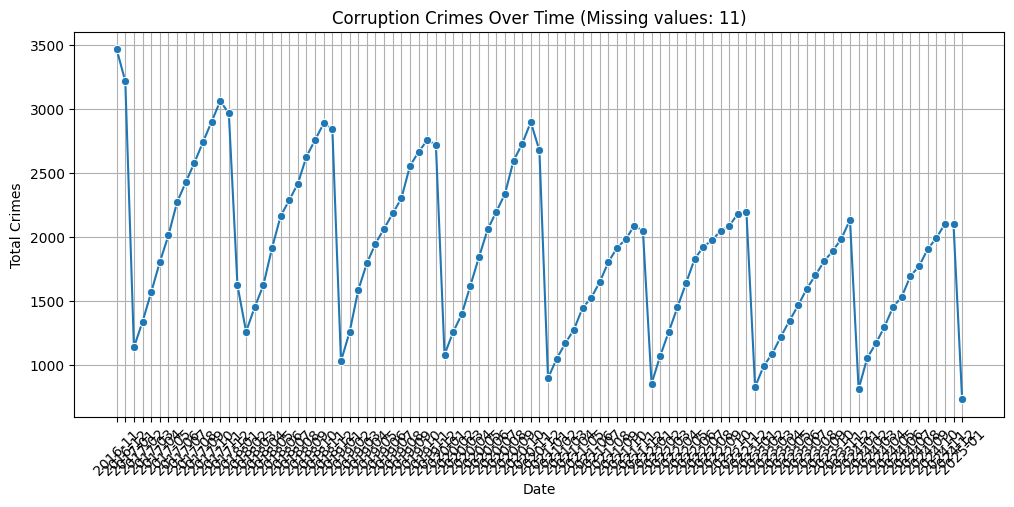

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the time series with missing values
plt.figure(figsize=(12, 5))
sns.lineplot(x="Date", y="Total Crimes", data=df, marker="o")
plt.title(f"Corruption Crimes Over Time (Missing values: {11})")
plt.xlabel("Date")
plt.ylabel("Total Crimes")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()